由于本人的电脑有一些兼容性问题，每个使用pytorch的脚本前需要先加入这么两行代码解决冲突问题。

In [13]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

接下来导入库，加载MNIST数据集

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
from urllib import request#我们选择用纯Numpy读取，因为难以解决的pillow环境冲突问题
import gzip
import os
def download_mnist(path="./data"):
    os.makedirs(path, exist_ok=True)
    base_url = "https://ossci-datasets.s3.amazonaws.com/mnist/"
    files = [
        "train-images-idx3-ubyte.gz",
        "train-labels-idx1-ubyte.gz",
        "t10k-images-idx3-ubyte.gz",
        "t10k-labels-idx1-ubyte.gz"
    ]
    for f in files:
        if not os.path.exists(os.path.join(path, f)):
            request.urlretrieve(base_url + f, os.path.join(path, f))
def load_mnist(path="./data", kind="train"):
    labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte.gz')
    images_path = os.path.join(path, f'{kind}-images-idx3-ubyte.gz')
    with gzip.open(labels_path, 'rb') as lbpath:
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8, offset=8)
    with gzip.open(images_path, 'rb') as imgpath:
        images = np.frombuffer(imgpath.read(), dtype=np.uint8, offset=16).reshape(len(labels), 28, 28)
    return images, labels
download_mnist()
train_images, train_labels = load_mnist(kind="train")
test_images, test_labels = load_mnist(kind="t10k")

下载好MNIST数据集后，我们创建数据集：

In [15]:
class MNISTDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32) / 255.0
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        return self.images[idx].unsqueeze(0), self.labels[idx]
train_dataset = MNISTDataset(train_images, train_labels)
test_dataset = MNISTDataset(test_images, test_labels)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [16]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(32*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x = self.conv(x)
        x = x.flatten(1)
        return self.fc(x)

In [17]:
model = CNN()
opt = optim.Adam(model.parameters())
loss_fn = nn.CrossEntropyLoss()
loss_history = []
acc_history = []
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model.train()
for batch_idx, (x, y) in enumerate(train_loader):
    opt.zero_grad()
    loss = loss_fn(model(x), y)
    loss.backward()
    opt.step()
    # 记录损失
    loss_history.append(loss.item())
    # 每 100 个 batch 打印一次 + 实时监控
    if batch_idx % 100 == 0:
        print(f"Batch {batch_idx:3d} | Loss: {loss.item():.4f}")

Batch   0 | Loss: 2.3161
Batch 100 | Loss: 0.3775
Batch 200 | Loss: 0.2288
Batch 300 | Loss: 0.1888
Batch 400 | Loss: 0.3092
Batch 500 | Loss: 0.1183
Batch 600 | Loss: 0.0690
Batch 700 | Loss: 0.0247
Batch 800 | Loss: 0.0837
Batch 900 | Loss: 0.0195


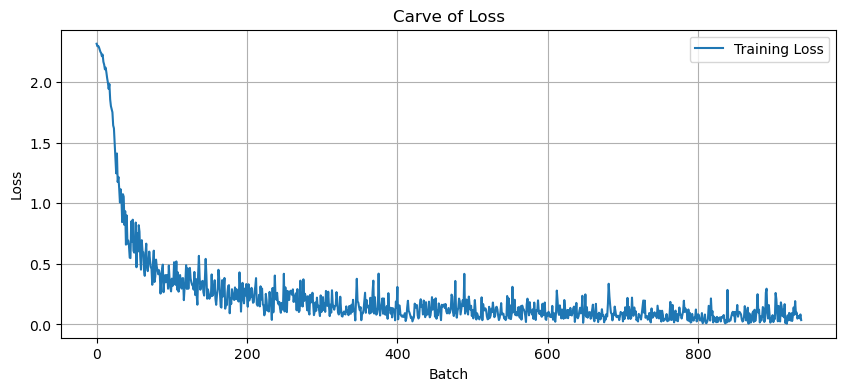

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(loss_history, label="Training Loss")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Carve of Loss")
plt.legend()
plt.grid(True)
plt.show()#本格子用来绘制损失率曲线

In [19]:
model.eval()
correct = 0
with torch.no_grad():
    for data, target in test_loader:
        output = model(data)
        pred = output.argmax(1)
        correct += (pred == target).sum().item()
print(f"准确率：{100 * correct / len(test_dataset):.2f}%")

准确率：97.98%
